In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [177]:
# csv pulled from arduino
df = pd.read_csv('arduino_pcr_data.csv')
df.head(10)

,time,cycle,stage,phase,temperature
0,0.0,1,denature,ramp,56.05
1,0.5,1,denature,ramp,56.99
2,1.0,1,denature,ramp,58.06
3,1.5,1,denature,ramp,59.15
4,2.0,1,denature,ramp,59.98
5,2.5,1,denature,ramp,60.98
6,3.0,1,denature,ramp,62.16
7,3.5,1,denature,ramp,63.08
8,4.0,1,denature,ramp,63.95
9,4.5,1,denature,ramp,65.05


In [149]:
df.tail(10)

,time,cycle,stage,phase,temperature
10027,5013.5,30,extension,hold,72.04
10028,5014.0,30,extension,hold,72.02
10029,5014.5,30,extension,hold,72.10
10030,5015.0,30,extension,hold,72.08
10031,5015.5,30,extension,hold,72.08
10032,5016.0,30,extension,hold,71.83
10033,5016.5,30,extension,hold,71.85
10034,5017.0,30,extension,hold,72.04
10035,5017.5,30,extension,hold,71.86
10036,5018.0,30,extension,hold,71.75


In [150]:
# info needed for PCR process
DENATURE_TEMP = 95
ANNEALING_TEMP = 55
EXTENSION_TEMP = 72

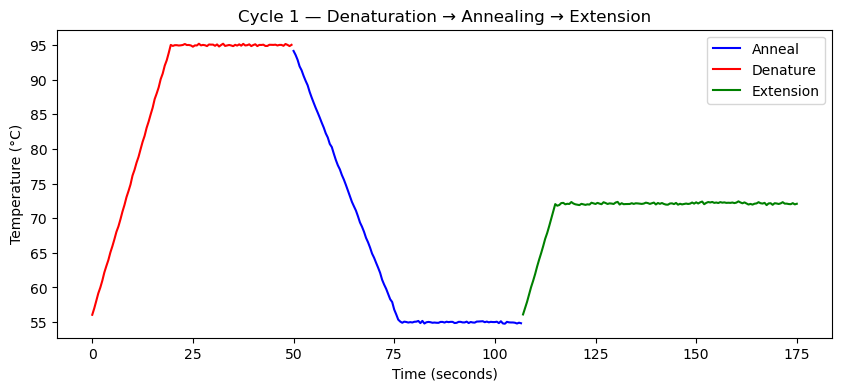

In [151]:
cycle1 = df[df['cycle'] == 1]
colors = {'denature': 'red', 'anneal': 'blue', 'extension': 'green'}

plt.figure(figsize=(10, 4))
for stage, group in cycle1.groupby('stage'):
  plt.plot(group['time'], 
           group['temperature'], 
           color=colors[stage], 
           label=stage.capitalize())

plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (°C)')
plt.title('Cycle 1 — Denaturation → Annealing → Extension')
plt.legend()
plt.show()


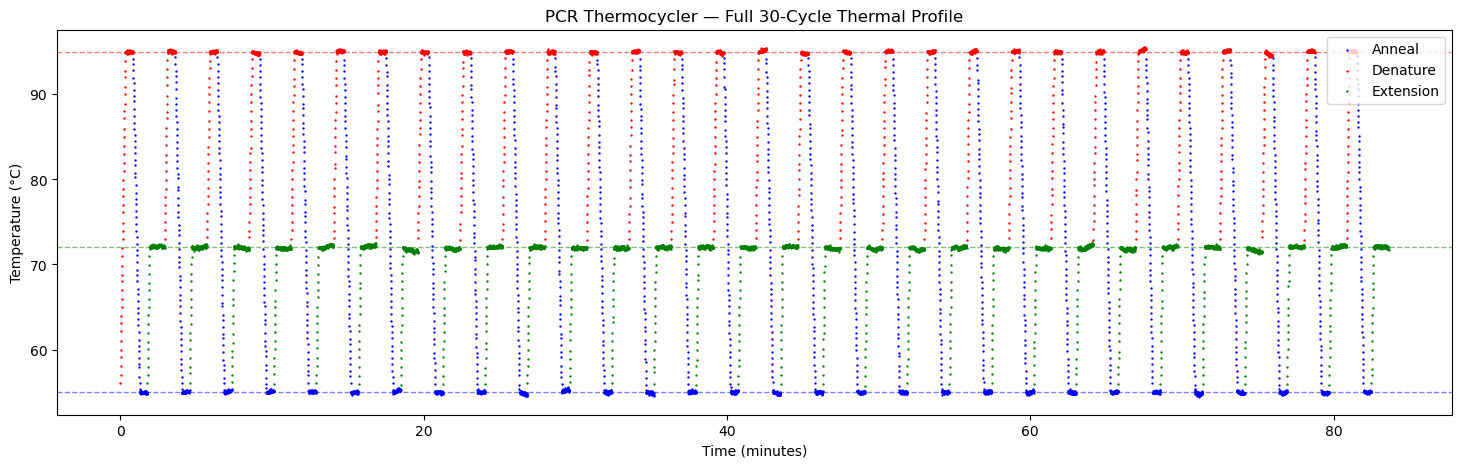

In [160]:
targets = {'denature': DENATURE_TEMP, 'anneal': ANNEALING_TEMP, 'extension': EXTENSION_TEMP}

plt.figure(figsize=(18, 5))
for stage, group in df.groupby('stage'):
    plt.scatter(group['time'] / 60,
                group['temperature'],
                s=0.5, # dot size, smaller is easier to read
                color=colors[stage], 
                label=stage.capitalize())

# stage = key, target = value
for stage, target in targets.items():
    plt.axhline(target, 
                color=colors[stage], 
                linestyle='--', 
                linewidth=1, # llength of dashed line at each cycle's ideal temperature 
                alpha=0.5) # how strong concentration of this dashed line 

plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C)')
plt.title('PCR Thermocycler — Full 30-Cycle Thermal Profile')
plt.legend()
plt.show()

In [183]:
# mean hold temperature per stage per cycle (during hold phase only)

tolerance = 1.5  # °C acceptable deviation from target

hold_df = df[df['phase'] == 'hold']
new_df = hold_df.groupby(['cycle', 'stage'])['temperature'].agg(['mean', 'std', 'min', 'max']).round(3)

new_df.columns = ['mean_temp', 'std_temp', 'min_temp', 'max_temp']
new_df = new_df.reset_index() # reverts two indices (cycle, stage) into one (0,1,2,etc)

# Flag cycles where mean deviated more than tolerance from target
new_df['target_temp'] = new_df['stage'].map(targets) # gets value for corresponding key
new_df['deviation'] = (new_df['mean_temp'] - new_df['target_temp']).abs().round(3)
new_df['within_tolerance'] = new_df['deviation'] <= tolerance

new_df.head()

,cycle,stage,mean_temp,std_temp,min_temp,max_temp,target_temp,deviation,within_tolerance
0,1,anneal,54.972,0.093,54.76,55.17,55,0.028,True
1,1,denature,94.984,0.097,94.76,95.19,95,0.016,True
2,1,extension,72.124,0.121,71.80,72.43,72,0.124,True
3,2,anneal,55.042,0.112,54.83,55.28,55,0.042,True
4,2,denature,95.062,0.112,94.77,95.28,95,0.062,True


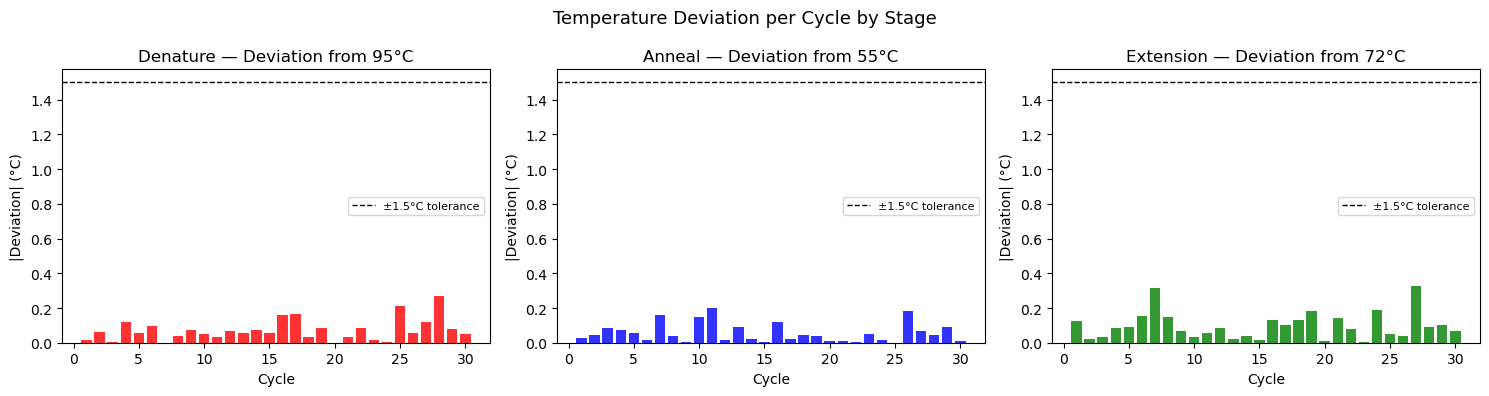

Deviations Summary
------------------
Denature: max(deviation) = 0.27, mean(deviation) = 0.07
Anneal: max(deviation) = 0.20, mean(deviation) = 0.06
Extension: max(deviation) = 0.33, mean(deviation) = 0.10

Deviation Findings
------------------
Average deviation across all stages: 0.076°C
Device holds temperature within ±0.33°C across all cycles
Extension has the highest deviation (0.33°C) — expected due to longest hold time (60s)


In [ ]:
# look at deviations to see if temperature is close enough to the target temperature for PCR to work

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
stage_names = ['denature', 'anneal', 'extension']

for ax, stage in zip(axes, stage_names):
    data = new_df[new_df['stage'] == stage]
    ax.bar(data['cycle'], data['deviation'], color=colors[stage], alpha=0.8)
    ax.axhline(tolerance, color='black', linestyle='--', linewidth=1, label=f'±{tolerance}°C tolerance')
    ax.set_title(f'{stage.capitalize()} — Deviation from {int(targets[stage])}°C')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('|Deviation| (°C)')
    ax.legend(fontsize=8)

plt.suptitle('Temperature Deviation per Cycle by Stage', fontsize=13)
plt.tight_layout()
plt.show()

# display findings
# REALLY GOOD findings!
print('Deviations Summary')
print('------------------')
for stage in stage_names:
    d = new_df[new_df['stage'] == stage]
    print(f"{stage.capitalize()}: max(deviation) = {d['deviation'].max():.2f}, mean(deviation) = {d['deviation'].mean():.2f}")

print('\nDeviation Findings')
print('------------------')
print(f"Average deviation across all stages: {new_df['deviation'].mean():.3f}°C")
print(f"Device holds temperature within ±{new_df['deviation'].max():.2f}°C across all cycles")
print(f"Extension has the highest deviation ({new_df[new_df['stage'] == 'extension']['deviation'].max():.2f}°C) — expected due to longest hold time (60s)")



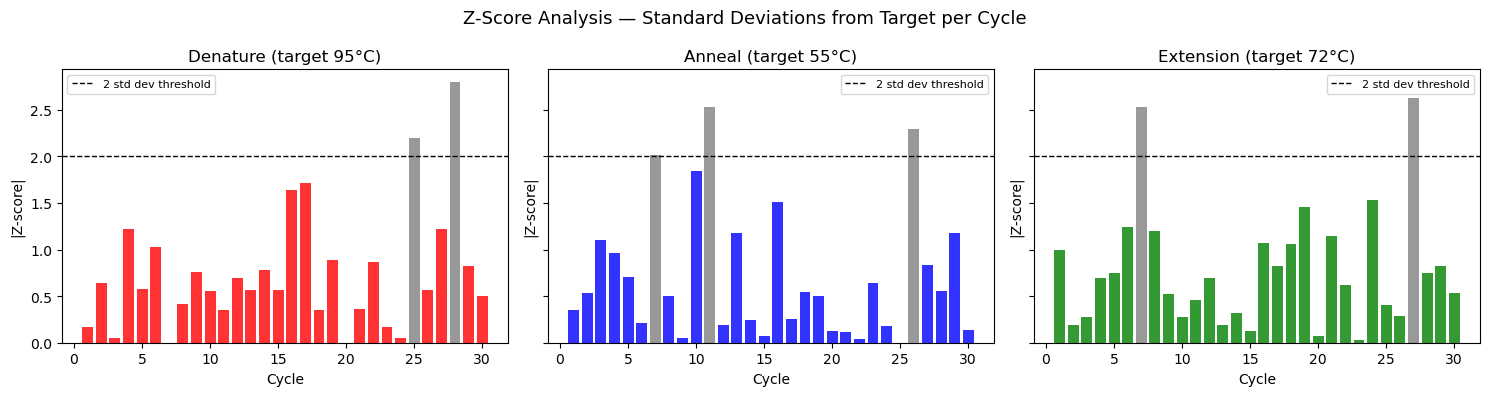

Z-Score Summary
---------------
Denature: max(z) = 2.79, mean(z) = 0.75
Anneal: max(z) = 2.53, mean(z) = 0.71
Extension: max(z) = 2.63, mean(z) = 0.79

Z-Score Findings
----------------
Cycles exceeding 2 std dev threshold: 7 out of 90
Mean z-score across all stages: 0.75 — thermocycler is within 1 std dev on average
Outliers are isolated incidents, not a consistent problem


In [191]:
# want to find z-score 
# how many standard deviations each cycle is from the target temperature
# z = (mean_temp - target) / std_across_cycles

# compute std of mean_temp across all 30 cycles for each stage
# std summarizes spread of entire stage, so only three unique values
for stage in stage_names:
    stage_mean_temp = new_df[new_df['stage'] == stage]['mean_temp']
    std = stage_mean_temp.std()
    new_df.loc[new_df['stage'] == stage, 'stage_std'] = std

# compute z-score and flag anything beyond 2 standard deviations
new_df['z_score'] = ((new_df['mean_temp'] - new_df['target_temp']) / new_df['stage_std']).abs().round(3)
new_df['within_2std'] = new_df['z_score'] <= 2

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, stage in zip(axes, stage_names):
    data = new_df[new_df['stage'] == stage]
    bar_colors = ['grey' if not w else colors[stage] for w in data['within_2std']]
    ax.bar(data['cycle'], data['z_score'], color=bar_colors, alpha=0.8)
    ax.axhline(2, color='black', linestyle='--', linewidth=1, label='2 std dev threshold')
    ax.set_title(f'{stage.capitalize()} (target {targets[stage]}°C)')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('|Z-score|')
    ax.legend(fontsize=8)

plt.suptitle('Z-Score Analysis — Standard Deviations from Target per Cycle', fontsize=13)
plt.tight_layout()
plt.show()

# display findings
print('Z-Score Summary')
print('---------------')
for stage in stage_names:
    d = new_df[new_df['stage'] == stage]
    print(f"{stage.capitalize()}: max(z) = {d['z_score'].max():.2f}, mean(z) = {d['z_score'].mean():.2f}")

print('\nZ-Score Findings')
print('----------------')
print(f"Cycles exceeding 2 std dev threshold: {(new_df['z_score'] > 2).sum()} out of {len(new_df)}")
print(f"Mean z-score across all stages: {new_df['z_score'].mean():.2f} — thermocycler is within 1 std dev on average")
print(f"Outliers are isolated incidents, not a consistent problem")
